<a href="https://colab.research.google.com/github/popolome/Singapore-HDB-Price-Intelligence-System/blob/main/Singapore_HDB_Price_Intelligence_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction


*   I tried to use the resource_id to scrape the historical data from Data.gov.sg of HDB resale pricing, but was hit with their rate limit. Error 429.
*   Next, I decided to just scrape the csv from their site instead.
*   It seems like I reached error 404, I had no choice but to manually download the csv file into my local and load it into Colab.
*   I spent like almost 3 hours to do the Geocoding for all 9000+ unique addresses. I saved it as a csv.
*   I then trained three different models and evaluate them.
*   **XGBoost model is the clear winner here** at MAE of about \$26,000, RMSE of about \$36,000, and R-square of 95%. This means the model is wrong about \$26,000 or about 4.3% from the actual price. The RMSE being close to \$26,000 means our model is not hallucinating. Finally, the R-square of 95% means our data why our price fluctuates, only 5% are not explained.
*   **Why Linear Regression fails because prices are not a straight line**, it cannot be explained fully with a straight line on the graph, prices fluctuates all around the graph, that is why it is off by so much.
*   I then plot the results out on a graph.

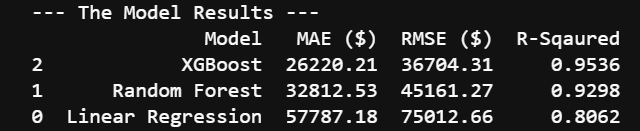

*   After plotting out the Feature Importance bar chart, I at first thought MRT distance will be one of the top importance feature affecting the price, but after looking at the chart, I was wrong, this is why we should never assume, data is always right.
*   The three most important features affecting the HDB price are floor_area_sqm, cbd_dist_km, and mid_storey. Let's explain why.
*   People are concern most about is how much space they are getting in their HDB flat, they are willing to pay more for it.
*   People does not care whether the MRT is close to their flat or not, but it has to be near the CBD area like Queenstown, Outram Park, etc.
*   People loves staying high up because they enjoy the view, away from ground-floor, less noisy, etc. These three features means people are willing to throw in more cash for it.

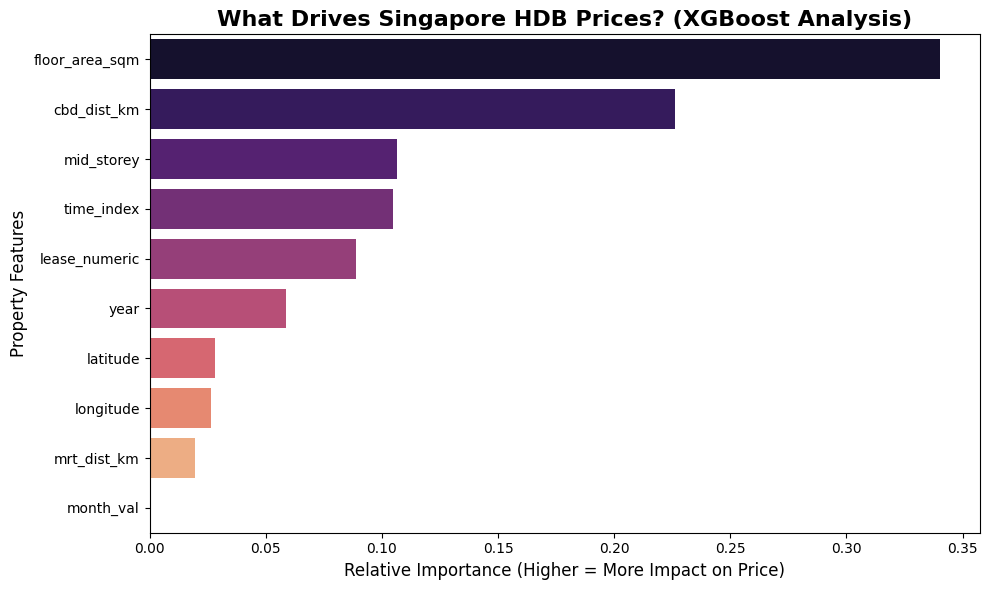

*   Finally, I saved as a pkl file and uploaded to GitHub Repo. Ready to be deployed.

# Summary
 XGBoost is the clear winner with a Mean Absolute Error (MAE) of ~$26,220. This suggests that on average, our model is within 4-5% of the actual transaction price, proving it is highly reliable for valuation. The 95% R-Squared indicates that our selected features capture nearly all the variance in HDB pricing, with only 5% attributed to unobserved factors like interior renovation quality or buyer sentiment.

 The discovery that cbd_dist_km is the #2 driver while mrt_dist_km is near the bottom is a significant market insight. It suggests that in modern Singapore, "Centrality" is a luxury, while "MRT Access" is now considered a standard utility that is already baked into almost every HDB location.



# Setup Requirements

In [14]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import json
import time
from google.colab import userdata
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import joblib
from tqdm.notebook import tqdm

# The Automated HDB Data Scaping

In [ ]:
# This loads in a downloaded csv from HDB site from 2017 and onwards on Resales
df = pd.read_csv("ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv")
print(f"Success! Total Rows Loaded: {len(df)}")
print(df.head())

Success! Total Rows Loaded: 227110
     month        town flat_type block        street_name storey_range  \
0  2017-01  ANG MO KIO    2 ROOM   406  ANG MO KIO AVE 10     10 TO 12   
1  2017-01  ANG MO KIO    3 ROOM   108   ANG MO KIO AVE 4     01 TO 03   
2  2017-01  ANG MO KIO    3 ROOM   602   ANG MO KIO AVE 5     01 TO 03   
3  2017-01  ANG MO KIO    3 ROOM   465  ANG MO KIO AVE 10     04 TO 06   
4  2017-01  ANG MO KIO    3 ROOM   601   ANG MO KIO AVE 5     01 TO 03   

   floor_area_sqm      flat_model  lease_commence_date     remaining_lease  \
0            44.0        Improved                 1979  61 years 04 months   
1            67.0  New Generation                 1978  60 years 07 months   
2            67.0  New Generation                 1980  62 years 05 months   
3            68.0  New Generation                 1980   62 years 01 month   
4            67.0  New Generation                 1980  62 years 05 months   

   resale_price  
0      232000.0  
1      250000.0

# Preprocessing for ML

In [ ]:
# This is a function to clean-up the HDB dataset
def clean_hdb_data(df):
  # This splits up dates to years, and dates into months
  df['year'] = df['month'].str.split('-').str[0].astype(int)
  df['month_val'] = df['month'].str.split('-').str[1].astype(int)
  df['time_index'] = df['year'] + (df['month_val'] / 12)

  # This is to convert floors from 05 to 5
  df['mid_storey'] = df['storey_range'].apply(lambda x: (int(x.split(' TO ')[0]) + int(x.split(' TO ')[1])) / 2)

  # This is to convert remaining lease to decimals
  def parse_lease(lease_str):
    if pd.isna(lease_str): return 99.0
    parts = str(lease_str).split()
    years = int(parts[0])
    months = int(parts[2]) if 'month' in str(lease_str) else 0
    return years + (months / 12)

  df['lease_numeric'] = df['remaining_lease'].apply(parse_lease)

  # This is to create a unique address for geocoding
  df['address'] = df['block'] + " " + df['street_name']

  return df

df = clean_hdb_data(df)
print("Data is cleaned! Ready for Geocoding.")

Data is cleaned! Ready for Geocoding.


# Geocoding


In [ ]:
onemap_credentials = {"email": userdata.get('email'), 'password': userdata.get('password')}

# This sets up the token
token = userdata.get('token')
headers = {"Authorization": token}

# This gets the unique addresses from df
unique_addresses = df['address'].unique()
print(f"Total unique addresses to geocode: {len(unique_addresses)}")

# This is the geocoding loop
address_coords = {}

# This tqdm will print a progress bar
for i, addr in enumerate(tqdm(unique_addresses, desc="Geocoding Address")):
  # This is the OneMap search API URL
  url = f"https://www.onemap.gov.sg/api/common/elastic/search?searchVal={addr}&returnGeom=Y&getAddrDetails=Y"

  try:
    response = requests.get(url, headers=headers)
    data = response.json()

    if data['results']:
      result = data['results'][0]
      address_coords[addr] = {
          'latitude': result['LATITUDE'],
          'longitude': result['LONGITUDE']
      }
    else:
      address_coords[addr] = {'latitude': None, 'longitude': None}

  except Exception as e:
      print(f"Error on {addr}: {e}")
      address_coords[addr] = {'latitude': None, 'longitude': None}

  # This is a short cooldown to wait for OneMap rate limits
  time.sleep(0.1)

print("Geocoding Complete!")

Total unique addresses to geocode: 9693
Progress: 0/9693 addresses mapped...
Progress: 500/9693 addresses mapped...
Progress: 1000/9693 addresses mapped...
Progress: 1500/9693 addresses mapped...
Progress: 2000/9693 addresses mapped...
Progress: 2500/9693 addresses mapped...
Progress: 3000/9693 addresses mapped...
Progress: 3500/9693 addresses mapped...
Progress: 4000/9693 addresses mapped...
Progress: 4500/9693 addresses mapped...
Progress: 5000/9693 addresses mapped...
Progress: 5500/9693 addresses mapped...
Progress: 6000/9693 addresses mapped...
Progress: 6500/9693 addresses mapped...
Progress: 7000/9693 addresses mapped...
Progress: 7500/9693 addresses mapped...
Progress: 8000/9693 addresses mapped...
Progress: 8500/9693 addresses mapped...
Progress: 9000/9693 addresses mapped...
Progress: 9500/9693 addresses mapped...
Geocoding Complete!


# Save Geocoding results as CSV

In [ ]:
# This will convert all columns to the df
coords_df = pd.DataFrame.from_dict(address_coords, orient='index').reset_index()
coords_df.columns = ['address', 'latitude', 'longitude']

# This will merge with our df
df = df.merge(coords_df, on='address', how='left')

# This will save our Geocoder as a CSV and no longer need to run again
df.to_csv("hdb_with_coords.csv", index=False)
print("Saved! Your dataset now has Latitude and Longitude.")

Saved! Your dataset now has Latitude and Longitude.


In [ ]:
# This will download the CSV to our local
files.download("hdb_with_coords.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Continue by inputting MRT locations to the CSV

In [ ]:
# This will load our completed CSV back in
print("Loading HDB data...")
df = pd.read_csv("hdb_with_coords.csv")

# This loads the public Singapore MRT dataset directly from Github
print("Loading MRT coordinates...")
mrt_url = "https://raw.githubusercontent.com/xkjyeah/MRT-and-LRT-Stations/master/mrt_lrt.csv"
mrt_df = pd.read_csv(mrt_url)

# This will allow us to use the Haversine Formula because the earth is round
def haversine(lat1, lon1, lat2, lon2):
  # This value is the earth's radius in kilometers
  R = 6371
  # This will convert degrees to radians
  lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

  dlat = lat2 - lat1
  dlon = lon2 - lon1

  a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
  c = 2 * np.arcsin(np.sqrt(a))
  return R * c

# This will optimize the calculation, only the unique calculation
print("Calculating distances...")
unique_coords = df[['address', 'latitude', 'longitude']].drop_duplicates().dropna(subset=['latitude', 'longitude'])

nearest_mrt_name = []
nearest_mrt_dist = []

for idx, row in unique_coords.iterrows():
  hdb_lat = row['latitude']
  hdb_lon = row['longitude']

  # This will calculate the distance from a single HDB block to all MRT stations
  distances = haversine(hdb_lat, hdb_lon, mrt_df['Latitude'], mrt_df['Longitude'])

  # This will grab the minimum distance and name of that station
  min_dist = distances.min()
  nearest_station = mrt_df.loc[distances.idxmin(), 'Name']

  nearest_mrt_dist.append(min_dist)
  nearest_mrt_name.append(nearest_station)

unique_coords['nearest_mrt'] = nearest_mrt_name
unique_coords['mrt_dist_km'] = nearest_mrt_dist

# This will calculate the distance to the CBD, Raffles Place MRT
unique_coords['cbd_dist_km'] = haversine(unique_coords['latitude'], unique_coords['longitude'], 1.2830, 103.8513)

# This will merge the features back to the main dataset
df = df.merge(unique_coords[['address', 'nearest_mrt', 'mrt_dist_km', 'cbd_dist_km']], on='address', how='left')

# This will save the final dataset
df.to_csv("hdb_model_ready.csv", index=False)
print("Dataset is ready for ML!")
print(df[['address', 'nearest_mrt', 'mrt_dist_km', 'cbd_dist_km']].head())

Loading HDB data...
Loading MRT coordinates...
Calculating distances...
Dataset is ready for ML!
                 address             nearest_mrt  mrt_dist_km  cbd_dist_km
0  406 ANG MO KIO AVE 10  ANG MO KIO MRT STATION     1.004026     8.789584
1   108 ANG MO KIO AVE 4   MAYFLOWER MRT STATION     0.189875     9.889191
2   602 ANG MO KIO AVE 5      LENTOR MRT STATION     0.535117    11.008129
3  465 ANG MO KIO AVE 10  ANG MO KIO MRT STATION     0.945539     9.274761
4   601 ANG MO KIO AVE 5      LENTOR MRT STATION     0.501151    11.048869


In [ ]:
files.download("hdb_model_ready.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Train Test Split on three models

In [2]:
# This will load the model-ready dataset
df = pd.read_csv("hdb_model_ready.csv")

# This only selects our X features and Y target, dropping columns like texts/IDs
features = ['year', 'month_val', 'time_index', 'mid_storey', 'lease_numeric',
            'floor_area_sqm', 'latitude', 'longitude', 'mrt_dist_km',
            'cbd_dist_km'
            ]

# This checks whether the columns are NaN and drop them
print("Missing values per column:")
print(df[features].isnull().sum())

df_clean = df.dropna(subset=features)

print(f"\nOriginal rows: {len(df)}")
print(f"\nCleaned rows: {len(df_clean)}")
print(f"Dropped {len(df) - len(df_clean)} rows due to missing geodata.")

# Then, we use the cleaned data as X and y
X = df_clean[features]
y = df_clean['resale_price']

# This performs train-test-split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training on {len(X_train)} flats, testing on {len(X_test)} flats.")

# This defines the three models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, max_depth=7, learning_rate=0.05, random_state=42, n_jobs=-1)
}

# This is storage for the results
results = []

print("Starting Model training...")

# This will train each model and predict them
for name, model in models.items():
  print(f"Training {name}...")
  model.fit(X_train, y_train)
  preds = model.predict(X_test)

  # This will evaluate the model's results
  mae = mean_absolute_error(y_test, preds)
  rmse = np.sqrt(mean_squared_error(y_test, preds))
  r2 = r2_score(y_test, preds)

  results.append({
      "Model": name,
      "MAE ($)": round(mae, 2),
      "RMSE ($)": round(rmse, 2),
      "R-Sqaured": round(r2, 4)
  })

# This displays the summary of all three models
leaderboard = pd.DataFrame(results).sort_values(by="MAE ($)")
print("\n--- The Model Results ---")
print(leaderboard)

Missing values per column:
year              1
month_val         1
time_index        1
mid_storey        1
lease_numeric     1
floor_area_sqm    1
latitude          1
longitude         1
mrt_dist_km       1
cbd_dist_km       1
dtype: int64

Original rows: 150561

Cleaned rows: 150560
Dropped 1 rows due to missing geodata.
Training on 120448 flats, testing on 30112 flats.
Starting Model training...
Training Linear Regression...
Training Random Forest...
Training XGBoost...

--- The Model Results ---
               Model   MAE ($)  RMSE ($)  R-Sqaured
2            XGBoost  26220.21  36704.31     0.9536
1      Random Forest  32812.53  45161.27     0.9298
0  Linear Regression  57787.18  75012.66     0.8062


# Plotting out the result

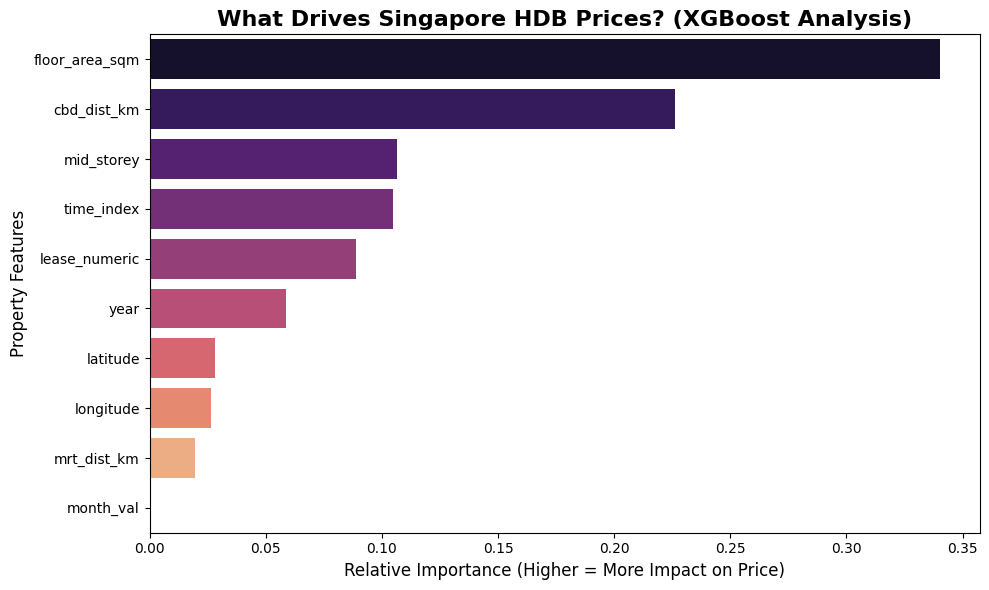

In [5]:
# This is get the fully trained model and plot it by feature importance
champion_model = models['XGBoost']
importances = champion_model.feature_importances_

# Then create a dataframe, sort it, and plot it as a bar chart
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})
# Sort it by the most to the least important
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Finally, plot it with a horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df,
    hue='Feature',
    palette='magma',
    legend=False
)

plt.title(
    "What Drives Singapore HDB Prices? (XGBoost Analysis)",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    "Relative Importance (Higher = More Impact on Price)",
    fontsize=12
)

plt.ylabel(
    "Property Features",
    fontsize=12
)

plt.tight_layout()
plt.show()

# Plot feature importance correlation heatmap

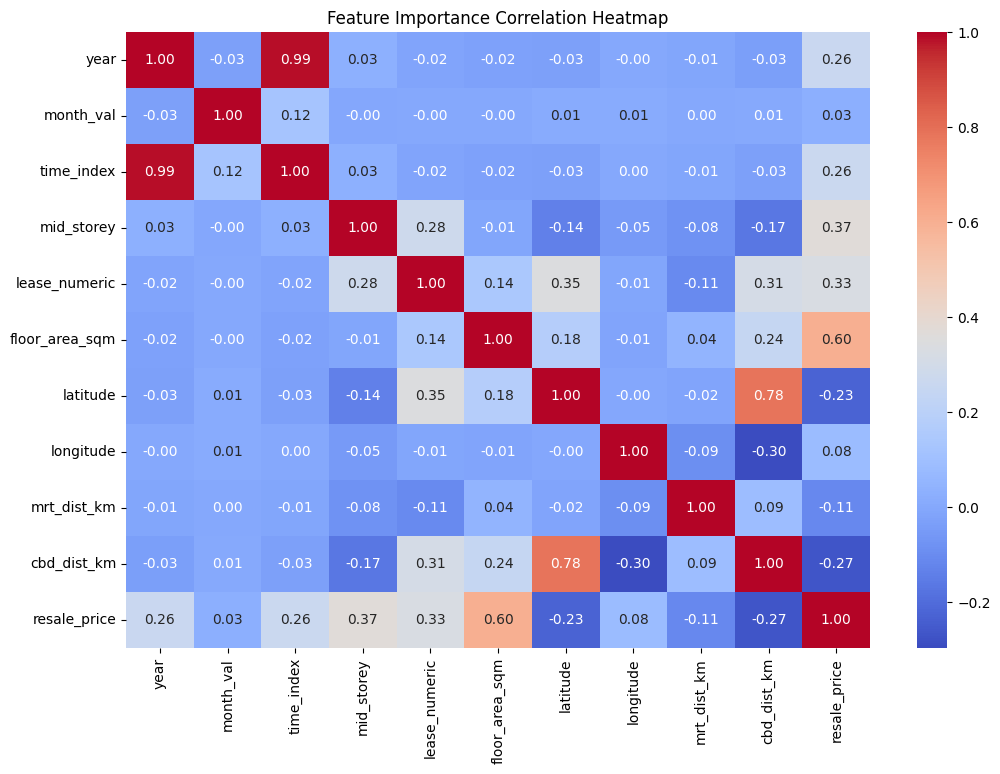

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    df[features + ['resale_price']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Importance Correlation Heatmap")
plt.show()

# Live Predictor Function

In [15]:
# This is a function for predicting other new data coming in
def predict_hdb_price(year, month, floor_area, mid_storey, lease_remain, lat, lon, mrt_dist, cbd_dist):
  input_data = pd.DataFrame([[
      year, month, year + (month/12), mid_storey, lease_remain, floor_area, lat, lon, mrt_dist, cbd_dist
  ]], columns=features)

  prediction = champion_model.predict(input_data)[0]
  return f"Estimated Resale Price: ${prediction:,.2f}"

# This is just an example data for prediction
print(predict_hdb_price(2026, 3, 90, 10, 85, 1.35, 103.85, 0.5, 2.5))

Estimated Resale Price: $818,529.56


# Save model as pkl file

In [9]:
# This will save the model
joblib.dump(models['XGBoost'], 'hdb_price_model.pkl')

# This will save the model's features
joblib.dump(features, 'model_features.pkl')

print("Model and Features saved successfully!")

Model and Features saved successfully!


# Final deployment test

In [16]:
# This is the final check when anyone using my model intends to run it
loaded_model = joblib.load('hdb_price_model.pkl')
test_pred = loaded_model.predict(X_test.iloc[[0]])
print(f"Test Load Successful! Predicted price for the first test: ${test_pred[0]:,.2f}")

Test Load Successful! Predicted price for the first test: $401,616.03
